# **Trabalho: Métodos de Previsão Aplicados**

#**2. Análise Exploratória de Dados**
## **2.1. Extração de dados**

### **Bibliotecas**

In [ ]:
# @title
!pip install statsforecast mlforecast utilsforecast

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 62.0/62.0 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 354.6/354.6 kB 15.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 128.1/128.1 kB 7.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 40.3/40.3 kB 2.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 348.2/348.2 kB 17.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 281.0/281.0 kB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 37.3/37.3 MB 18.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 419.5/419.5 kB 26.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 59.9/59.9 kB 4.8 MB/s eta 0:00:00
  Attempting uninstall: scipy
    Found existing installation: scipy 1.16.3
    Uninstalling scipy-1.16.3:
      Successfully uninstalled scipy-1.16.3


In [ ]:
# @title
import requests
import json
import pandas as pd
from bs4 import BeautifulSoup
from datetime import datetime
import holidays
import matplotlib.pyplot as plt
from mlforecast import MLForecast
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from utilsforecast.losses import mae, rmse, mape
from utilsforecast.evaluation import evaluate
from mlforecast.utils import PredictionIntervals
from statsforecast import StatsForecast
from statsforecast.models import SeasonalNaive, AutoETS, AutoARIMA, MSTL


### **Função extração**

In [ ]:
# @title
#Função extração
def extract_data_atendimentos_nos_csp_gripe(ars, start_date, end_date, cols=['no_consultas_gripe_nos_csp']):
    """
    Extracts daily data from the dataset 'Atendimentos nos CSP - Gripe'
    available at the SNS Transparency Portal.

    Parameters
    ----------
    ars : str
        Health region name used in the dataset (e.g., 'Norte', 'Centro',
        'Lisboa e Vale do Tejo', 'Alentejo', 'Algarve').
    start_date : str (YYYY-MM-DD)
        Start date of the extraction interval (inclusive).
    end_date : str (YYYY-MM-DD)
        End date of the extraction interval (inclusive).
    cols : list of str, optional
        Names of the variables to retain in the returned DataFrame.
        By default, keeps the influenza-related consultation count.

    Returns
    -------
    pandas.DataFrame
        A tidy DataFrame indexed by date, filtered by region and time
        interval, containing the selected variables.
    """
    indicator = "atendimentos-nos-csp-gripe"
    base_url = f"https://transparencia.sns.gov.pt/api/explore/v2.1/catalog/datasets/{indicator}/records"

    limit = 100
    df_data = pd.DataFrame()

    date_ranges = pd.date_range(start=start_date, end=end_date, freq=f"{limit}D", inclusive="left")

    for i, s_date in enumerate(date_ranges):
        s_date = s_date.strftime("%Y-%m-%d")
        e_date = (date_ranges[i + 1] - pd.Timedelta("1D")).strftime("%Y-%m-%d") if i < len(date_ranges) - 1 else end_date

        params = {
            "where": f'regiao="{ars}" AND dia>=date\'{s_date}\' AND dia<=date\'{e_date}\'',
            "limit": limit
        }

        response = requests.get(base_url, params=params)
        response.raise_for_status()

        data_extract = response.json()
        df_aux = pd.json_normalize(data_extract.get("results", []))

        if not df_aux.empty:
            df_data = pd.concat([df_data, df_aux], ignore_index=True)

    if not df_data.empty:
        df_data["dia"] = pd.to_datetime(df_data["dia"], errors="coerce")
        for c in cols:
            if c in df_data.columns:
                df_data[c] = pd.to_numeric(df_data[c], errors="coerce")
        df_data = df_data.dropna(subset=["dia"]).sort_values("dia").reset_index(drop=True)
        df_data = df_data.filter(["dia"] + cols)

    return df_data

### **Executar a extração para o Centro**



---



<class 'pandas.core.frame.DataFrame'>
RangeIndex: 518 entries, 0 to 517
Data columns (total 2 columns):
 #   Column                      Non-Null Count  Dtype         
---  ------                      --------------  -----         
 0   dia                         518 non-null    datetime64[ns]
 1   no_consultas_gripe_nos_csp  518 non-null    float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 8.2 KB


None

,dia,no_consultas_gripe_nos_csp
513,2026-01-27,112.0
514,2026-01-28,58.0
515,2026-01-29,65.0
516,2026-01-30,63.0
517,2026-01-31,10.0


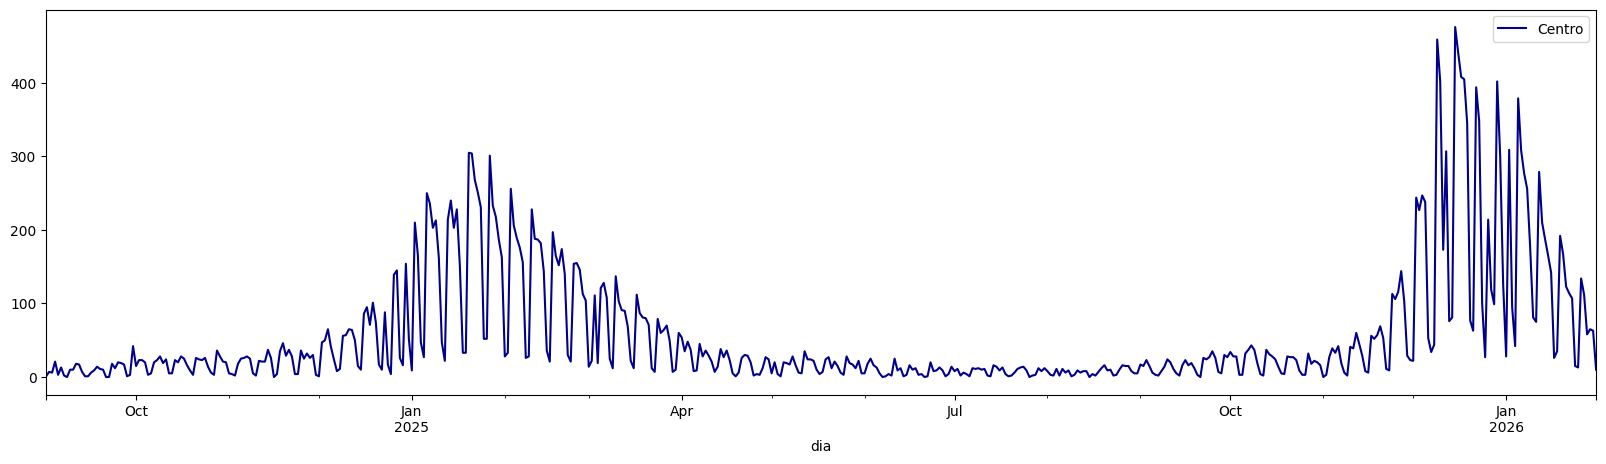

In [ ]:
#Extração para a região Centro
df_centro = extract_data_atendimentos_nos_csp_gripe(
    ars="Centro",
    start_date="2024-09-01",
    end_date="2026-01-31"
)
display(df_centro.info())
display(df_centro.tail())
df_centro.plot(x="dia", y="no_consultas_gripe_nos_csp", figsize=(20,5), label="Centro", color="darkblue");

In [ ]:
df_centro_ts = (df_centro
    .assign(dia = lambda x: pd.to_datetime(x.dia).dt.to_period("D")) # 1º e 2º passo: datetime e periodicidade 'D' (diária)
    .set_index("dia")                                               # 3º passo: definir como índice
    .sort_index()                                                   # Extra: garantir que as datas estão por ordem
)

# Aplicar o asfreq('D') para garantir que não faltam dias (como ensinado no NB1)
df_centro = df_centro_ts.asfreq('D')

display(df_centro.info(), df_centro_ts.head(3), df_centro_ts.tail(3))

<class 'pandas.core.frame.DataFrame'>
PeriodIndex: 518 entries, 2024-09-01 to 2026-01-31
Freq: D
Data columns (total 1 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   no_consultas_gripe_nos_csp  518 non-null    float64
dtypes: float64(1)
memory usage: 8.1 KB


None

,no_consultas_gripe_nos_csp
dia,
2024-09-01,1.0
2024-09-02,7.0
2024-09-03,6.0


,no_consultas_gripe_nos_csp
dia,
2026-01-29,65.0
2026-01-30,63.0
2026-01-31,10.0


In [ ]:
print("df_centro freq: ", df_centro.index.freq)

try:
    print(df_centro.index.inferred_freq)
except Exception:
    print("df_centro inferred_freq: Erro")

df_centro freq:  <Day>
df_centro inferred_freq: Erro


In [ ]:
import holidays

# 1. Criar calendário de feriados oficiais
pt_holidays = holidays.Portugal(years=[2023, 2024, 2025, 2026])

# 2. Lista manual (Greves e Tolerâncias)
datas_extra = [
    '2023-07-05', '2023-07-06', '2023-07-25', '2023-07-26', '2023-07-27',
    '2023-08-09', '2023-08-10', '2023-12-26', '2024-01-02', '2024-07-23',
    '2024-07-24', '2024-09-24', '2024-09-25', '2024-12-24', '2024-12-31',
    '2025-10-23', '2025-12-10', '2025-12-24', '2025-12-26', '2025-12-31',
    '2026-02-17'
]
datas_extra_dt = pd.to_datetime(datas_extra).date

# 3. Função de verificação (Lógica da tua amiga)
def verifica_nao_util(data):
    # data aqui será um Timestamp do pandas vindo do índice
    if data.weekday() >= 5:
        return 1  # Fim de semana
    if data in pt_holidays:
        return 1  # Feriado oficial
    if data.date() in datas_extra_dt:
        return 1  # Greve ou Tolerância
    return 0

# 4. Aplicar ao DataFrame (Mantendo o estilo da professora)
# Criamos a coluna 'nao_util' que resume tudo (feriados, fds, greves)
df_centro['nao_util'] = df_centro.index.to_timestamp().map(verifica_nao_util)

# 5. Adicionar também o dia_semana (útil para o modelo aprender o padrão de cada dia)
df_centro['dia_semana'] = df_centro.index.to_timestamp().weekday

print("Engenharia de Atributos completa (Feriados, Greves e Fim de Semana):")
display(df_centro.query("nao_util == 1").tail(10))

Engenharia de Atributos completa (Feriados, Greves e Fim de Semana):


,no_consultas_gripe_nos_csp,nao_util,dia_semana
dia,,,
2026-01-01,28.0,1,3
2026-01-03,95.0,1,5
2026-01-04,42.0,1,6
2026-01-10,81.0,1,5
2026-01-11,75.0,1,6
2026-01-17,26.0,1,5
2026-01-18,35.0,1,6
2026-01-24,15.0,1,5
2026-01-25,13.0,1,6


## **3. Metodologia**




In [ ]:
!pip install mlforecast window_ops utilsforecast

#### 3.1. Estratégia experimental para comparação

Metodos de previsao estatisticos

In [ ]:
#  DATAFRAME BASE (Sem variáveis extras)
Y_df_base = (
    df_centro
    .reset_index()
    .rename(columns={'dia': 'ds', 'no_consultas_gripe_nos_csp': 'y'})
    .assign(unique_id='ARS_Centro')
    .filter(['unique_id', 'ds', 'y']) # Apenas o essencial
)
Y_df_base['ds'] = Y_df_base['ds'].dt.to_timestamp()

#  DATAFRAME EXÓGENO (Com as variáveis extra)
Y_df_exog = (
    df_centro
    .reset_index()
    .rename(columns={'dia': 'ds', 'no_consultas_gripe_nos_csp': 'y'})
    .assign(unique_id='ARS_Centro')
    .filter(['unique_id', 'ds', 'y', 'nao_util', 'dia_semana'])
)
Y_df_exog['ds'] = Y_df_exog['ds'].dt.to_timestamp()

In [ ]:
from statsforecast.models import SeasonalNaive, AutoETS, AutoARIMA, MSTL

# 1. Lista de Modelos BASE (Só usam o histórico 'y')
models_base = [
    SeasonalNaive(season_length=7),
    AutoETS(season_length=7),
    AutoARIMA(season_length=7, alias='AutoARIMA_Base'),
    MSTL(season_length=[7], alias='MSTL_Base')
]

# 2. Lista de Modelos EXOG (Vão usar 'nao_util' e 'dia_semana')
models_exog = [
    # O AutoARIMA deteta automaticamente as colunas extras no DataFrame
    AutoARIMA(season_length=7, alias='AutoARIMA_Exog'),

    # O MSTL também usará as colunas extras se passadas no DataFrame
    MSTL(season_length=[7], alias='MSTL_Exog')
]

# 3. Lista completa
models_stat = models_base + models_exog

In [ ]:
from statsforecast import StatsForecast
import pandas as pd

# 1. Validação para Modelos BASE (usando Y_df_base)
sf_base = StatsForecast(
    models=models_base,
    freq='D',
    n_jobs=1
)
cv_base = sf_base.cross_validation(
    df=Y_df_base,
    h=10,
    step_size=1,
    n_windows=7
)

# 2. Validação para Modelos EXOG (usando Y_df_exog)
sf_exog = StatsForecast(
    models=models_exog,
    freq='D',
    n_jobs=1
)
cv_exog = sf_exog.cross_validation(
    df=Y_df_exog,
    h=10,
    step_size=1,
    n_windows=7
)

# 3. Unir os resultados numa única tabela cv_stats
# Removemos 'y' e 'cutoff' da segunda tabela para não duplicar colunas
cv_stats = pd.merge(
    cv_base,
    cv_exog.drop(columns=['y', 'cutoff']),
    on=['unique_id', 'ds']
)

# 4. Arredondar para inteiros e garantir que não há negativos
colunas_modelos = [col for col in cv_stats.columns if col not in ['unique_id', 'ds', 'cutoff', 'y']]
cv_stats[colunas_modelos] = cv_stats[colunas_modelos].clip(lower=0).round(0).astype(int)

display(cv_stats.head())

,unique_id,ds,cutoff,y,SeasonalNaive,AutoETS,AutoARIMA_Base,MSTL_Base,AutoARIMA_Exog,MSTL_Exog
0,ARS_Centro,2026-01-16,2026-01-15,142.0,177,191,164,210,170,210
1,ARS_Centro,2026-01-17,2026-01-15,26.0,81,61,67,49,57,49
2,ARS_Centro,2026-01-17,2026-01-15,26.0,81,61,67,49,44,24
3,ARS_Centro,2026-01-18,2026-01-15,35.0,75,42,51,32,40,32
4,ARS_Centro,2026-01-18,2026-01-15,35.0,75,42,51,32,38,7


In [ ]:
# 1. Identificar as colunas dos modelos (as previsões)
cols_modelos = [col for col in cv_stats.columns if col not in ['unique_id', 'ds', 'cutoff', 'y']]

#Travar no 0
cv_stats[cols_modelos] = cv_stats[cols_modelos].clip(lower=0).round(0)

sf_exog.plot(Y_df_exog, cv_stats.drop(columns=['y', 'cutoff'], errors='ignore'), engine='plotly')

#### Métodos de Previsão ML

In [ ]:
# 1. Preparação (Obrigatório para StatsForecast/MLForecast)
df_ml = df_centro.reset_index()
df_ml = df_ml.rename(columns={'dia': 'ds', 'no_consultas_gripe_nos_csp': 'y'})
df_ml['unique_id'] = 'ARS_Centro'

# Converter Period para Timestamp (Nixtla não aceita Period)
df_ml['ds'] = df_ml['ds'].dt.to_timestamp()

# Manter as colunas exógenas que criaste (nao_util, dia_semana)
# Elas serão usadas como 'static' ou 'dynamic' features se quiseres
df_ml.head(5)

,ds,y,nao_util,dia_semana,unique_id
0,2024-09-01,1.0,1,6,ARS_Centro
1,2024-09-02,7.0,0,0,ARS_Centro
2,2024-09-03,6.0,0,1,ARS_Centro
3,2024-09-04,21.0,0,2,ARS_Centro
4,2024-09-05,3.0,0,3,ARS_Centro


In [ ]:
from mlforecast import MLForecast
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor

modelos_grid = {}

# Grid Search RF
for prof in [5, 10, None]:
    for n_arv in [100, 200]:
        modelos_grid[f'RF_d{prof}_n{n_arv}'] = RandomForestRegressor(max_depth=prof, n_estimators=n_arv, random_state=42)

# Grid Search XGB
for taxa in [0.05, 0.1]:
    modelos_grid[f'XGB_lr{taxa}'] = XGBRegressor(learning_rate=taxa, n_estimators=100, random_state=42)

# Configurar o MLForecast
fcst_ml = MLForecast(
    models=modelos_grid,
    freq='D',
    lags=[7, 14], # Importante: Captura a sazonalidade semanal
    date_features=['dayofweek'] # Extrai automaticamente o dia da semana
)

print(f"Total de modelos em teste: {len(modelos_grid)}")

Total de modelos em teste: 8


In [ ]:
# Backtesting / Cross-Validation
res_cv = fcst_ml.cross_validation(
    df=df_ml,
    h=10,                   # Prever 1 semana
    n_windows=7,           # 14 janelas de teste
    step_size=1,           # Avançar de semana em semana
    static_features=[]     # ESTA LINHA RESOLVE O ERRO
)

display(res_cv.head())

,unique_id,ds,cutoff,y,RF_d5_n100,RF_d5_n200,RF_d10_n100,RF_d10_n200,RF_dNone_n100,RF_dNone_n200,XGB_lr0.05,XGB_lr0.1
0,ARS_Centro,2026-01-16,2026-01-15,142.0,277.943851,265.225499,278.376667,269.879667,286.22,270.545,223.599136,240.170517
1,ARS_Centro,2026-01-17,2026-01-15,26.0,75.374037,75.711501,85.330640,85.809021,84.79,85.730,87.781349,83.339676
2,ARS_Centro,2026-01-18,2026-01-15,35.0,78.302649,81.281311,93.958773,97.269942,94.88,96.255,86.293396,87.148979
3,ARS_Centro,2026-01-19,2026-01-15,192.0,253.763600,260.077172,270.312520,273.216597,269.18,270.830,290.428864,300.992218
4,ARS_Centro,2026-01-20,2026-01-15,167.0,244.372376,239.166360,238.174167,234.523787,235.52,232.385,249.997955,255.538544


In [ ]:
from utilsforecast.plotting import plot_series

# 1. Identificar as colunas dos modelos ML (RF e XGB) que estão na res_cv
cols_ml = [c for c in res_cv.columns if c not in ['unique_id', 'ds', 'cutoff', 'y']]

# 2. "Travar" no zero (IMPORTANTE: usar res_cv em ambos os lados)
res_cv[cols_ml] = res_cv[cols_ml].clip(lower=0)

# 3. Gerar o gráfico (Corrigido: forecasts_df e sem o drop do 'y' para comparação)
plot_series(
    df=df_ml,
    forecasts_df=res_cv.drop(columns=['cutoff'], errors='ignore'),
    engine='plotly'
)

#### 3.2. Métricas de avaliação da capacidade preditiva

nao tem codigo porque é muito teorico :)

### 3.3. Preparação dos dados

In [ ]:
# 3.3. PREPARAÇÃO DOS DADOS (FEATURE ENGINEERING)
from window_ops.rolling import rolling_mean

# 1. Variáveis Exógenas (Feriados e Fins de Semana)
df_ml['fds'] = df_ml['ds'].dt.dayofweek.isin([5, 6]).astype(int)
df_ml['feriado'] = 0
lista_feriados = ['01-01', '04-25', '05-01', '06-10', '08-15', '10-05', '11-01', '12-01', '12-08', '12-25']
df_ml.loc[df_ml['ds'].dt.strftime('%m-%d').isin(lista_feriados), 'feriado'] = 1

# 2. Configuração do MLForecast com Lags e Transformações
fcst_ml = MLForecast(
    models=modelos_grid,
    freq='D',
    lags=[4, 5, 6, 7, 14],
    lag_transforms={
        1: [(rolling_mean, 7)] # Capta a tendência da última semana - media movel
    },
    date_features=['dayofweek']
)

print("Dados preparados: Lags a partir de h=4 e variáveis de calendário incluídas.")

Dados preparados: Lags a partir de h=4 e variáveis de calendário incluídas.


### 4. Resultado e Discussão


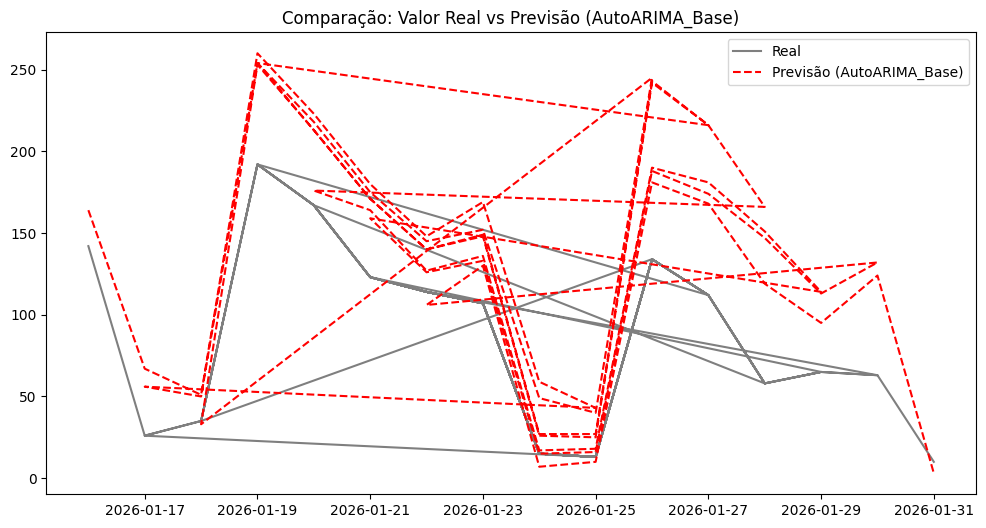

In [ ]:
import matplotlib.pyplot as plt

# 1. Primeiro, garantimos que o ranking_final é criado
# (Cálculo das métricas para os modelos estatísticos)
metricas_estatisticas = evaluate(
    df=cv_stats,
    metrics=[mae, rmse],
    target_col='y'
)

# Criar o ranking
ranking_final = metricas_estatisticas.drop(columns=['unique_id']).groupby('metric').mean(numeric_only=True).T
ranking_final.columns = [col.upper() for col in ranking_final.columns]
ranking_final = ranking_final.sort_values('MAE')

# Escolhe o melhor modelo
melhor_modelo = ranking_final.index[0]

plt.figure(figsize=(12, 6))
plt.plot(cv_stats['ds'], cv_stats['y'], label='Real', color='black', alpha=0.5)
plt.plot(cv_stats['ds'], cv_stats[melhor_modelo], label=f'Previsão ({melhor_modelo})', color='red', linestyle='--')
plt.title(f'Comparação: Valor Real vs Previsão ({melhor_modelo})')
plt.legend()
plt.show()



In [ ]:
# 1. Avaliação no estilo exato da professora
# O .round(2) no fim deixa a tabela limpa e profissional
evaluate(
    cv_stats.drop(columns=['cutoff'], errors='ignore'),
    metrics=[rmse, mae, mape],
).round(2)

,unique_id,metric,SeasonalNaive,AutoETS,AutoARIMA_Base,MSTL_Base,AutoARIMA_Exog,MSTL_Exog
0,ARS_Centro,rmse,66.28,61.66,49.88,66.37,52.12,66.37
1,ARS_Centro,mae,57.63,48.06,40.49,52.21,41.13,52.21
2,ARS_Centro,mape,1.12,0.73,0.63,0.69,0.55,0.69


In [ ]:
# Avaliação exata no estilo da professora
evaluate(
    res_cv.drop(columns=['cutoff'], errors='ignore'),
    metrics=[rmse, mae], # mape costuma dar erro se houver zeros nos dados reais
).round(2)

,unique_id,metric,RF_d5_n100,RF_d5_n200,RF_d10_n100,RF_d10_n200,RF_dNone_n100,RF_dNone_n200,XGB_lr0.05,XGB_lr0.1
0,ARS_Centro,rmse,85.40,82.96,84.06,80.91,87.24,82.39,73.63,77.88
1,ARS_Centro,mae,74.92,73.05,74.94,72.11,77.00,73.44,64.47,68.93
